# Fundamentals of NLP — Assignment 2
**Student:** Muhammad Umer Shehzad  
**Roll No:** BS-23-IB-101047  
**Due Date:** 09-03-2026  

---
## Contents
- **Part 1** — Build N-gram Language Models (Bigrams & Trigrams) for 3 Corpora
- **Part 2** — Sentence Generation (Simple Probability & Shannon's Method)
- **Part 3** — Out-of-Domain Test Set (200 sentences) & Performance Evaluation
- **Part 4** — Urdu Fake News Detection using Naive Bayes Variants

---
## Step 1 — Install & Import Required Libraries

In [1]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

import subprocess, sys

required = ['nltk', 'pdfplumber', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn']
for pkg in required:
    try:
        __import__(pkg.replace('-', '_').replace('scikit_learn', 'sklearn'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages ready!')

Installing pdfplumber...
All packages ready!


---
## Step 2 — Extract RAR Files
All data files are in `.rar` format in the same folder as this notebook.  
This cell installs `rarfile`, detects the available extraction backend (`unrar` / `bsdtar` / `7z`),  
and extracts each archive before any corpus is loaded.

In [2]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

import subprocess, sys, os, shutil
from pathlib import Path

# ── Install rarfile ───────────────────────────────────────────────────
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rarfile', '-q'])
import rarfile

# ── Locate a working RAR extraction tool ─────────────────────────────
def _find_unrar_tool():
    """Try to locate unrar / bsdtar / 7z on the system."""
    for tool in ('unrar', 'bsdtar', '7z'):
        if shutil.which(tool):
            return tool
    return None

tool = _find_unrar_tool()
if tool:
    rarfile.UNRAR_TOOL = shutil.which(tool)
    print(f'Using extraction tool: {tool}  →  {rarfile.UNRAR_TOOL}')
else:
    # Try to install unrar automatically (Linux / Colab)
    try:
        subprocess.check_call(['apt-get', 'install', '-y', 'unrar'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        rarfile.UNRAR_TOOL = shutil.which('unrar')
        print(f'unrar installed automatically: {rarfile.UNRAR_TOOL}')
    except Exception:
        print('WARNING: No unrar tool found. Install unrar manually if extraction fails.')

# ── RAR archives to extract ───────────────────────────────────────────
# Maps: rar_filename → extraction folder (None = extract into a folder
#       with the same stem as the archive)
RAR_FILES = {
    'LM_1_Corpus.rar'              : 'LM_1_Corpus',
    'BERP_Transcription.rar'       : 'BERP_Transcription',
    'Google_Scholar.rar'           : 'Google_Scholar',
    'Training Dataset@FIRE2021.rar': 'Training Dataset@FIRE2021',
    'Test Dataset @ FIRE 2021.rar' : 'Test Dataset @ FIRE 2021',
}

def extract_rar(rar_path, dest_dir):
    """
    Extract a RAR archive to dest_dir.
    Skips extraction if dest_dir already exists and is non-empty.
    """
    rar_path = Path(rar_path)
    dest_dir = Path(dest_dir)

    if not rar_path.exists():
        print(f'  [SKIP] {rar_path.name} — file not found')
        return False

    if dest_dir.exists() and any(dest_dir.iterdir()):
        print(f'  [SKIP] {rar_path.name} — already extracted to {dest_dir}/')
        return True

    dest_dir.mkdir(parents=True, exist_ok=True)
    try:
        with rarfile.RarFile(str(rar_path)) as rf:
            rf.extractall(str(dest_dir))
        print(f'  [OK]   {rar_path.name}  →  {dest_dir}/')
        return True
    except Exception as e:
        print(f'  [ERR]  {rar_path.name}: {e}')
        return False

print('=' * 55)
print('Extracting RAR archives...')
print('=' * 55)

for rar_name, dest in RAR_FILES.items():
    extract_rar(rar_name, dest)

# ── Resolve BERP text file path (handles nested folders) ─────────────
def find_file(root, filename):
    """Recursively find the first file matching filename under root."""
    for p in Path(root).rglob(filename):
        return str(p)
    return None

berp_found = find_file('BERP_Transcription', 'BERP_Transcription.txt')
BERP_PATH_RESOLVED = berp_found if berp_found else 'BERP_Transcription/BERP_Transcription.txt'

# ── Resolve FIRE 2021 dataset path (handles nested folders) ──────────
def find_dir(root, dirname):
    """Recursively find the first directory matching dirname under root."""
    for p in Path(root).rglob(dirname):
        if p.is_dir():
            return str(p)
    return None

# Look for the folder that actually contains Train/ and Test/ subdirectories
fire_root = 'Training Dataset@FIRE2021'
fire_found = None
for p in Path(fire_root).rglob('Train'):
    if p.is_dir():
        fire_found = str(p.parent)
        break
FIRE_PATH_RESOLVED = fire_found if fire_found else fire_root

print('\nResolved paths:')
print(f'  LM_1_Corpus     : LM_1_Corpus/')
print(f'  BERP            : {BERP_PATH_RESOLVED}')
print(f'  Google Scholar  : Google_Scholar/')
print(f'  FIRE Train/Test : {FIRE_PATH_RESOLVED}')
print(f'  Stop words      : stopwords-ur.txt')
print('\nExtraction complete!')

Using extraction tool: unrar  →  /usr/bin/unrar
Extracting RAR archives...
  [OK]   LM_1_Corpus.rar  →  LM_1_Corpus/
  [OK]   BERP_Transcription.rar  →  BERP_Transcription/
  [OK]   Google_Scholar.rar  →  Google_Scholar/
  [OK]   Training Dataset@FIRE2021.rar  →  Training Dataset@FIRE2021/
  [OK]   Test Dataset @ FIRE 2021.rar  →  Test Dataset @ FIRE 2021/

Resolved paths:
  LM_1_Corpus     : LM_1_Corpus/
  BERP            : BERP_Transcription/BERP_Transcription.txt
  Google Scholar  : Google_Scholar/
  FIRE Train/Test : Training Dataset@FIRE2021/Training Dataset@FIRE2021/Training Dataset@FIRE2021
  Stop words      : stopwords-ur.txt

Extraction complete!


In [3]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

import nltk
import re
import os
import math
import random
import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.util import ngrams
from nltk import FreqDist, ConditionalFreqDist
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK resources
for resource in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger']:
    try:
        nltk.download(resource, quiet=True)
    except:
        pass

# Reproducibility
random.seed(42)
np.random.seed(42)

print('Libraries imported successfully!')

Libraries imported successfully!


---
# PART 1 — N-gram Language Models
Build bigram (n=2) and trigram (n=3) language models from three corpora:
1. **LM_1_Corpus** — provided academic PDFs
2. **BeRP** — Berkeley Restaurant Project transcriptions (NLTK / provided file)
3. **Google Scholar** — downloaded publications from the provided profile

## 1.1 — NGramLanguageModel Class

In [70]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

class NGramLanguageModel:
    """
    General-purpose N-gram Language Model.
    Supports any order n, Laplace (add-1) and add-k smoothing.
    """

    def __init__(self, n=2, smoothing='laplace', k=1.0):
        """
        Parameters
        ----------
        n         : int   — order of n-gram (2=bigram, 3=trigram)
        smoothing : str   — 'laplace' (add-1) or 'addk' (add-k)
        k         : float — smoothing constant (used when smoothing='addk')
        """
        self.n = n
        self.smoothing = smoothing
        self.k = k
        self.ngram_freq    = FreqDist()   # counts of each n-gram
        self.context_freq  = FreqDist()   # counts of each (n-1)-gram context
        self.vocab         = set()
        self.sentence_count = 0
        self.total_ngrams   = 0

    # ------------------------------------------------------------------
    def _normalize_tokens(self, text):
      """
      Light per-sentence normalization AFTER sentence splitting.
      Only now do we remove punctuation — sentence boundaries are already found.
      """
      text = text.lower()
      text = re.sub(r'https?://\S+',   ' ', text)   # URLs
      text = re.sub(r'doi:\S+',        ' ', text)   # DOIs
      text = re.sub(r'[^\w\s]',        ' ', text)   # punctuation
      text = re.sub(r'\d+',            ' ', text)   # digits
      text = re.sub(r'\b\w\b',         ' ', text)   # single-char tokens
      text = re.sub(r'\s+',            ' ', text)   # whitespace
      return text.strip()

    def tokenize_text(self, text):
      """
      Full pipeline: heuristic segmentation → normalize → word-tokenize.

      Order matters:
        1. heuristic_segment()  — split into sentences using punctuation cues
        2. _normalize_tokens()  — THEN strip punctuation / digits per sentence
        3. word_tokenize()      — split into word tokens
      Boundary markers <s> and </s> are added for n-gram context.
      """
      # Step 1 — sentence segmentation (uses punctuation, must come first)
      raw_sentences = heuristic_segment(text)

      tokenized = []
      for sent in raw_sentences:
          # Step 2 — normalize (remove punctuation, lowercase, etc.)
          cleaned = self._normalize_tokens(sent)
          if not cleaned.strip():
              continue

          # Step 3 — word tokenize + add boundary markers
          tokens = (['<s>'] * (self.n - 1)
                    + word_tokenize(cleaned)
                    + ['</s>'])
          tokens = [t for t in tokens if t.strip()]

          if len(tokens) > self.n + 1:   # skip trivially short sentences
              tokenized.append(tokens)

      return tokenized

    # ------------------------------------------------------------------
    def build_model(self, sentences):
        """Build frequency tables from a list of tokenised sentences."""
        for sent in sentences:
            self.sentence_count += 1
            for token in sent:
                self.vocab.add(token)
            for gram in ngrams(sent, self.n):
                self.ngram_freq[gram]        += 1
                self.context_freq[gram[:-1]] += 1
                self.total_ngrams            += 1

        print(f'Model built (n={self.n}, smoothing={self.smoothing}):'
              f'\n  Sentences : {self.sentence_count}'
              f'\n  Vocab     : {len(self.vocab):,}'
              f'\n  N-grams   : {self.total_ngrams:,}'
              f'\n  Unique    : {len(self.ngram_freq):,}')

    # ------------------------------------------------------------------
    def get_probability(self, gram):
        """
        Conditional probability P(w_n | w_1 ... w_{n-1}) with smoothing.
        """
        context = gram[:-1]
        V       = len(self.vocab)

        if self.smoothing == 'laplace':
            num = self.ngram_freq[gram]         + 1
            den = self.context_freq[context]    + V
        elif self.smoothing == 'addk':
            num = self.ngram_freq[gram]         + self.k
            den = self.context_freq[context]    + self.k * V
        else:   # no smoothing
            if self.context_freq[context] == 0:
                return 0.0
            num = self.ngram_freq[gram]
            den = self.context_freq[context]

        return num / den if den > 0 else 0.0

    # ------------------------------------------------------------------
    def sentence_probability(self, tokens):
        """Product of conditional probabilities for a tokenised sentence."""
        return math.prod(self.get_probability(g) for g in ngrams(tokens, self.n))

    def sentence_log_probability(self, tokens):
        """Sum of log-probabilities (numerically stable)."""
        lp = 0.0
        for g in ngrams(tokens, self.n):
            p = self.get_probability(g)
            lp += math.log(p) if p > 0 else float('-inf')
        return lp

    # ------------------------------------------------------------------
    def perplexity(self, test_sentences):
        """
        Perplexity on a list of tokenised test sentences.
        Lower = better model.
        """
        total_lp, total_n = 0.0, 0
        for sent in test_sentences:
            grams = list(ngrams(sent, self.n))
            total_n += len(grams)
            for g in grams:
                p = self.get_probability(g)
                total_lp += math.log(p) if p > 0 else math.log(1e-10)
        if total_n == 0:
            return float('inf')
        return math.exp(-total_lp / total_n)

    # ------------------------------------------------------------------
    def top_ngrams(self, top_n=10):
        """Print the top_n most frequent n-grams with their probabilities."""
        print(f'\nTop {top_n} {self.n}-grams:')
        print(f'  {"N-gram":<45} {"Count":>7}  {"P(w|context)":>14}')
        print('  ' + '-' * 70)
        for gram, cnt in self.ngram_freq.most_common(top_n):
            p = self.get_probability(gram)
            print(f'  {str(gram):<45} {cnt:>7}  {p:>14.6f}')

print('NGramLanguageModel class defined.')

NGramLanguageModel class defined.


In [71]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047
# ── PREPROCESSING MODULE ──────────────────────────────────────────────

import unicodedata

# ══════════════════════════════════════════════════════════════════════
# A) PDF TEXT CLEANING
#    Fix artifacts introduced by pdfplumber BEFORE any NLP processing.
# ══════════════════════════════════════════════════════════════════════

def clean_pdf_text(text):
    """
    Fix common artifacts from PDF text extraction.
    Preserves sentence-ending punctuation so segmentation still works.

    Steps
    -----
    1. NFKC unicode normalization → resolves ligatures (ﬁ→fi, ﬂ→fl, ﬀ→ff)
    2. Fix hyphenated line-breaks  (dis-\\nambiguation → disambiguation)
    3. Collapse soft line-wraps to spaces
    4. Remove in-text citation markers [1], [2,3], [1-5]
    5. Remove standalone page-number lines
    6. Drop short ALL-CAPS lines (likely headers/footers)
    7. Normalize whitespace
    """
    # 1. Resolve ligatures and compatibility characters
    text = unicodedata.normalize('NFKC', text)

    # 2. Rejoin hyphenated line-breaks: "infor-\nmation" → "information"
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)

    # 3. Soft line wraps → single space (preserve paragraph breaks \n\n)
    text = re.sub(r'(?<!\n)\n(?!\n)', ' ', text)

    # 4. Remove citation markers: [1], [2, 3], [1-5], [23]
    text = re.sub(r'\[\s*\d[\d,\-\s]*\]', ' ', text)

    # 5. Remove lines that are only a page number
    text = re.sub(r'^\s*\d{1,4}\s*$', '', text, flags=re.MULTILINE)

    # 6. Remove short ALL-CAPS header/footer lines
    #    (≤6 words where ≥60% of words are fully uppercase)
    cleaned_lines = []
    for line in text.split('\n'):
        words = line.strip().split()
        if (1 <= len(words) <= 6 and
                sum(1 for w in words if w.isupper()) / len(words) >= 0.6):
            continue   # skip — looks like a running title or section label
        cleaned_lines.append(line)
    text = '\n'.join(cleaned_lines)

    # 7. Collapse excessive whitespace
    text = re.sub(r'[ \t]+',  ' ',   text)
    text = re.sub(r'\n{3,}',  '\n\n', text)

    return text.strip()


# ══════════════════════════════════════════════════════════════════════
# B) HEURISTIC SENTENCE SEGMENTATION  (English)
#    More robust than NLTK sent_tokenize for noisy academic text.
#    Key idea: split on ". " + capital letter UNLESS the period belongs
#    to a known abbreviation, an initial, or a number.
# ══════════════════════════════════════════════════════════════════════

# Abbreviations that should NEVER trigger a sentence break
_ABBREVS = {
    'et', 'al', 'fig', 'dr', 'mr', 'mrs', 'ms', 'prof', 'inc', 'ltd',
    'vs', 'vol', 'no', 'pp', 'pg', 'ed', 'eds', 'approx', 'max', 'min',
    'avg', 'eq', 'ref', 'dept', 'univ', 'sec', 'jan', 'feb', 'mar',
    'apr', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'etc',
    'e.g', 'i.e', 'cf', 'ibid', 'op', 'ca', 'st', 'ave', 'blvd',
    'repr', 'rev', 'est', 'approx', 'govt', 'corp',
}

def heuristic_segment(text):
    """
    Rule-based sentence segmenter for academic English text.

    Rules
    -----
    - Primary split signal : '. ' or '! ' or '? ' followed by a capital
    - Suppress split if    : last token is a known abbreviation
                             last token is a single capital letter (initial)
                             period follows a digit  (3.14, 2019.)
                             next word starts lowercase
    - Also split on        : double newlines (paragraph breaks)
    Returns list of sentence strings.
    """
    sentences = []

    # First split on paragraph breaks
    for para in re.split(r'\n{2,}', text):
        para = re.sub(r'\s+', ' ', para).strip()
        if not para:
            continue

        # Candidate split points: sentence-ending punctuation + whitespace + capital
        # We use a lookahead so the capital letter stays with the next sentence
        chunks = re.split(r'(?<=[.!?])\s+(?=[A-Z\"])', para)

        buffer = ''
        for chunk in chunks:
            if buffer:
                # Last word before the split point
                last_tok = re.split(r'\s+', buffer.rstrip())[-1].rstrip('.!?')

                suppress = (
                    last_tok.lower() in _ABBREVS          # known abbreviation
                    or (len(last_tok) == 1
                        and last_tok.isupper())            # single initial  J.
                    or bool(re.search(r'\d$', last_tok))  # ends with digit
                    or bool(re.match(r'[a-z]', chunk))    # next word lowercase
                )

                if suppress:
                    buffer += ' ' + chunk
                    continue

            if buffer.strip():
                sentences.append(buffer.strip())
            buffer = chunk

        if buffer.strip():
            sentences.append(buffer.strip())

    # Filter trivially short results
    return [s for s in sentences if len(s.split()) > 2]


# ══════════════════════════════════════════════════════════════════════
# C) URDU TEXT NORMALIZATION  (Part 4)
#    Standardize character variants before tokenization.
# ══════════════════════════════════════════════════════════════════════

# Map Arabic character variants → standard Urdu equivalents
_URDU_CHAR_MAP = {
    'ك': 'ک',   # Arabic kaf       → Urdu kaf
    'ي': 'ی',   # Arabic ya        → Urdu ya
    'ى': 'ی',   # Alef maqsura     → Urdu ya
    'ه': 'ہ',   # Arabic ha        → Urdu ha (ہ)
    'ة': 'ت',   # Ta marbuta       → ta
    'ؤ': 'و',   # Waw with hamza   → waw
    'إ': 'ا',   # Alef with hamza below → alef
    'أ': 'ا',   # Alef with hamza above → alef
    'آ': 'ا',   # Alef with madda  → alef
}

# Arabic-Indic digits → ASCII digits
_ARABIC_INDIC = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')

# Diacritics / tashkeel range
_DIACRITICS = re.compile(r'[\u064B-\u065F\u0670\u0610-\u061A]')

def urdu_normalize(text):
    """
    Normalize Urdu text before tokenization.

    Steps
    -----
    1. NFKC unicode normalization
    2. Normalize Arabic character variants to Urdu equivalents
    3. Remove diacritics / tashkeel (ً ٌ ٍ َ ُ ِ ّ ْ)
    4. Remove tatweel / kashida  (ـ)
    5. Remove zero-width and direction control characters
    6. Normalize Urdu punctuation to ASCII equivalents
    7. Translate Arabic-Indic digits to ASCII digits
    8. Collapse repeated whitespace
    """
    # 1. NFKC
    text = unicodedata.normalize('NFKC', text)

    # 2. Character variant normalization
    for src, tgt in _URDU_CHAR_MAP.items():
        text = text.replace(src, tgt)

    # 3. Remove diacritics
    text = _DIACRITICS.sub('', text)

    # 4. Remove tatweel (kashida stretch)
    text = text.replace('\u0640', '')

    # 5. Remove zero-width / direction control characters
    text = re.sub(r'[\u200B-\u200F\u202A-\u202E\u2060\uFEFF]', '', text)

    # 6. Urdu/Arabic punctuation → ASCII equivalents
    text = (text
            .replace('۔', '.')    # Urdu full stop
            .replace('؟', '?')    # Arabic question mark
            .replace('،', ',')    # Arabic comma
            .replace('؛', ';')    # Arabic semicolon
            .replace('«', '"')
            .replace('»', '"'))

    # 7. Arabic-Indic digits → ASCII
    text = text.translate(_ARABIC_INDIC)

    # 8. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print('Preprocessing module loaded:')
print('  clean_pdf_text()    — fixes PDF extraction artifacts')
print('  heuristic_segment() — rule-based sentence segmentation')
print('  urdu_normalize()    — Urdu character normalization')

Preprocessing module loaded:
  clean_pdf_text()    — fixes PDF extraction artifacts
  heuristic_segment() — rule-based sentence segmentation
  urdu_normalize()    — Urdu character normalization


## 1.2 — Corpus Loading Utilities

In [72]:

def _clean(text):
        """Normalise raw text before tokenisation."""
        text = text.lower()
        text = re.sub(r'https?://\S+', ' ', text)   # remove URLs
        text = re.sub(r'doi:\S+',      ' ', text)   # remove DOIs
        text = re.sub(r'\d+',          ' ', text)   # remove digits
        text = re.sub(r'[^\w\s]',      ' ', text)   # remove punctuation
        text = re.sub(r'\s+',          ' ', text)   # collapse whitespace
        return text.strip()

def extract_text_from_pdfs(corpus_path):
    """
    Extract and concatenate text from all PDFs in corpus_path.
    Returns a single string.
    """
    all_text = ''
    pdfs = sorted(Path(corpus_path).glob('*.pdf'))
    print(f'Found {len(pdfs)} PDF(s) in: {corpus_path}')
    for pdf in pdfs:
        try:
            with pdfplumber.open(str(pdf)) as doc:
                for page in doc.pages:
                    t = page.extract_text()
                    if t:
                        all_text += clean_pdf_text(t) + ' '
            print(f'  [OK] {pdf.name}')
        except Exception as e:
            print(f'  [ERR] {pdf.name}: {e}')
    print(f'Total characters extracted: {len(all_text):,}')
    return all_text


def load_berp(path):
    """
    Load BERP transcription file.
    Format: <ID> <sentence text>
    Returns joined text string.
    """
    sentences = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split(None, 1)
                if len(parts) > 1:
                    sentences.append(parts[1])
    text = ' '.join(sentences)
    print(f'BERP loaded: {len(sentences):,} utterances, {len(text):,} characters')
    return text

print('Corpus loading utilities defined.')

Corpus loading utilities defined.


## 1.3 — Load Corpus 1: LM_1_Corpus

In [73]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

LM1_PATH = 'LM_1_Corpus/LM_1_Corpus'   # extracted from LM_1_Corpus.rar

print('=' * 60)
print('CORPUS 1 — LM_1_Corpus')
print('=' * 60)
lm1_text = extract_text_from_pdfs(LM1_PATH)
print(f'\nPreview (first 300 chars):\n{lm1_text[:300]}...')

CORPUS 1 — LM_1_Corpus
Found 6 PDF(s) in: LM_1_Corpus/LM_1_Corpus
  [OK] GCLUSIM.pdf
  [OK] JIS-hussain2018.pdf
  [OK] KER_Hussain.pdf
  [OK] LUCID_CR.pdf
  [OK] Turkish.pdf
  [OK] elk-27-5-28-1806-132.pdf
Total characters extracted: 324,179

Preview (first 300 chars):
Author Name Disambiguation by Exploiting Graph Structural Clustering and Hybrid Similarity Ijaz Hussain & Sohail Asghar Arabian Journal for Science and Engineering ISSN 2193-567X Arab J Sci Eng DOI 10.1007/s13369-018-3099-0 1 23 Your article is protected by copyright and all rights are held exclusiv...


## 1.4 — Load Corpus 2: BeRP

In [74]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

BERP_PATH = BERP_PATH_RESOLVED   # auto-resolved after RAR extraction

print('=' * 60)
print('CORPUS 2 — Berkeley Restaurant Project (BeRP)')
print('=' * 60)

try:
    berp_text = load_berp(BERP_PATH)
    print(f'\nPreview (first 300 chars):\n{berp_text[:300]}...')
except FileNotFoundError:
    print('BERP file not found — using built-in NLTK sample as fallback.')
    # Fallback: sample restaurant sentences
    sample = [
        "I want to find a restaurant that serves chinese food.",
        "Can you recommend a good italian place near downtown?",
        "I would like to eat somewhere inexpensive.",
        "Tell me about restaurants open on sunday.",
        "I want a place with outdoor seating.",
    ] * 200
    berp_text = ' '.join(sample)
    print(f'Using {len(sample)} sample restaurant sentences ({len(berp_text):,} chars).')

CORPUS 2 — Berkeley Restaurant Project (BeRP)
BERP loaded: 8,566 utterances, 303,092 characters

Preview (first 300 chars):
okay let's see i want to go to a thai restaurant . [uh] with less than ten dollars per person <i> <like> <to> <eat> [uh] i like to eat at lunch time . so that would be eleven a__m to one p__m i don't want to walk for more than five minutes tell me more about the [uh] na- nakapan [uh] restaurant on m...


## 1.5 — Load Corpus 3: Google Scholar Publications

In [84]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

SCHOLAR_PATH = 'Google_Scholar/Google_Scholar'   # extracted from Google_Scholar.rar

print('=' * 60)
print('CORPUS 3 — Google Scholar Publications')
print('=' * 60)
scholar_text = extract_text_from_pdfs(SCHOLAR_PATH)
print(f'\nPreview (first 300 chars):\n{scholar_text[:300]}...')

CORPUS 3 — Google Scholar Publications
Found 20 PDF(s) in: Google_Scholar/Google_Scholar
  [OK] 1-s2.0-S1568494625004028-main.pdf
  [OK] 1-s2.0-S1568494626002097-main.pdf
  [OK] 1-s2.0-S1877050915009412-main.pdf
  [OK] 1206.5361v1.pdf
  [OK] 21stIBCAST2024_paper_208.pdf
  [OK] 565-Article Text-3165-1-10-20230312.pdf
  [OK] 571-Article Text-3170-1-10-20230312.pdf
  [OK] A_Comprehensive_Survey_on_Urdu_Hate_Speech_Detection_Methods_Evaluation_and_Challenges.pdf
  [OK] Effect of preprocessing 571-Article Text-3170-1-10-20230312.pdf
  [OK] Heart desease prediction 565-Article Text-3165-1-10-20230312.pdf
  [OK] Incremental author name disambiguation using author profile model.pdf
  [OK] LUCID_paper.pdf
  [OK] MUST_An_Explainable_AI-Based_Framework_for_Multilingual_Hate_Speech_Detection.pdf
  [OK] Name_Disambiguation_Techniques_Survey.pdf
  [OK] Resolving namesakes using the authors social network.pdf
  [OK] Stuxnet_Applied Soft Computing Paper.pdf
  [OK] healthcare-14-00282-v2.pdf
  [OK] s11

## 1.6 — Build Bigram Models (n=2)

In [85]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

print('=' * 60)
print('BIGRAM MODELS (n=2, Laplace smoothing)')
print('=' * 60)

# --- LM1 ---
print('\n[1] LM_1_Corpus')
bigram_lm1 = NGramLanguageModel(n=2, smoothing='laplace')
bigram_lm1.build_model(bigram_lm1.tokenize_text(lm1_text))
bigram_lm1.top_ngrams(10)

# --- BeRP ---
print('\n[2] BeRP')
bigram_berp = NGramLanguageModel(n=2, smoothing='laplace')
bigram_berp.build_model(bigram_berp.tokenize_text(berp_text))
bigram_berp.top_ngrams(10)

# --- Scholar ---
print('\n[3] Google Scholar')
bigram_scholar = NGramLanguageModel(n=2, smoothing='laplace')
bigram_scholar.build_model(bigram_scholar.tokenize_text(scholar_text))
bigram_scholar.top_ngrams(10)

BIGRAM MODELS (n=2, Laplace smoothing)

[1] LM_1_Corpus
Model built (n=2, smoothing=laplace):
  Sentences : 1218
  Vocab     : 6,343
  N-grams   : 32,103
  Unique    : 18,352

Top 10 2-grams:
  N-gram                                          Count    P(w|context)
  ----------------------------------------------------------------------
  ('in', 'the')                                     170        0.024425
  ('<s>', 'in')                                     132        0.017590
  ('of', 'the')                                     129        0.018240
  ('name', 'disambiguation')                        117        0.017776
  ('author', 'name')                                112        0.016691
  ('to', 'the')                                      81        0.012161
  ('<s>', 'the')                                     76        0.010184
  ('et', 'al')                                       73        0.011534
  ('number', 'of')                                   72        0.011378
  ('the', 'same

## 1.7 — Build Trigram Models (n=3)

In [86]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

print('=' * 60)
print('TRIGRAM MODELS (n=3, Laplace smoothing)')
print('=' * 60)

# --- LM1 ---
print('\n[1] LM_1_Corpus')
trigram_lm1 = NGramLanguageModel(n=3, smoothing='laplace')
trigram_lm1.build_model(trigram_lm1.tokenize_text(lm1_text))
trigram_lm1.top_ngrams(10)

# --- BeRP ---
print('\n[2] BeRP')
trigram_berp = NGramLanguageModel(n=3, smoothing='laplace')
trigram_berp.build_model(trigram_berp.tokenize_text(berp_text))
trigram_berp.top_ngrams(10)

# --- Scholar ---
print('\n[3] Google Scholar')
trigram_scholar = NGramLanguageModel(n=3, smoothing='laplace')
trigram_scholar.build_model(trigram_scholar.tokenize_text(scholar_text))
trigram_scholar.top_ngrams(10)

TRIGRAM MODELS (n=3, Laplace smoothing)

[1] LM_1_Corpus
Model built (n=3, smoothing=laplace):
  Sentences : 1218
  Vocab     : 6,343
  N-grams   : 32,103
  Unique    : 24,566

Top 10 3-grams:
  N-gram                                          Count    P(w|context)
  ----------------------------------------------------------------------
  ('<s>', '<s>', 'in')                              132        0.017590
  ('<s>', '<s>', 'the')                              76        0.010184
  ('author', 'name', 'disambiguation')               66        0.010380
  ('<s>', '<s>', 'they')                             51        0.006877
  ('hussain', 'and', 'asghar')                       43        0.006889
  ('<s>', 'in', 'the')                               40        0.006332
  ('turk', 'elec', 'eng')                            33        0.005332
  ('elec', 'eng', 'comp')                            33        0.005332
  ('eng', 'comp', 'sci')                             33        0.005332
  ('<s>', '<s>

## 1.8 — Sentence Probability Demonstration

In [87]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# Demo: compute probability of arbitrary sentences
demo_sentences = [
    "author name disambiguation is an important task",
    "i want to find a restaurant",
    "machine learning models require careful evaluation",
]

print(f'{"Sentence":<50} {"Model":<20} {"Log-Prob":>12}')
print('-' * 86)

for raw in demo_sentences:
    tokens = ['<s>'] + word_tokenize(raw.lower()) + ['</s>']
    for name, model in [
        ('LM1 Bigram',     bigram_lm1),
        ('BeRP Bigram',    bigram_berp),
        ('Scholar Bigram', bigram_scholar),
    ]:
        lp = model.sentence_log_probability(tokens)
        print(f'{raw[:48]:<50} {name:<20} {lp:>12.4f}')
    print()

Sentence                                           Model                    Log-Prob
--------------------------------------------------------------------------------------
author name disambiguation is an important task    LM1 Bigram               -56.6917
author name disambiguation is an important task    BeRP Bigram              -58.3600
author name disambiguation is an important task    Scholar Bigram           -60.2907

i want to find a restaurant                        LM1 Bigram               -58.7523
i want to find a restaurant                        BeRP Bigram              -43.7541
i want to find a restaurant                        Scholar Bigram           -63.6019

machine learning models require careful evaluati   LM1 Bigram               -58.7008
machine learning models require careful evaluati   BeRP Bigram              -51.9835
machine learning models require careful evaluati   Scholar Bigram           -56.0203



---
# PART 2 — Sentence Generation
Two generation strategies:
1. **Simple Probability** (greedy / deterministic) — always pick the most probable next word
2. **Shannon's Method** (stochastic) — sample next word from the probability distribution

In [88]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

class SentenceGenerator:
    """
    Generates sentences from a trained NGramLanguageModel.

    Methods
    -------
    simple_probability : greedy — always select argmax P(w|context)
    shannon            : stochastic — sample w ~ P(w|context)
    generate           : unified interface
    """

    def __init__(self, model):
        self.model = model
        self.n     = model.n

    # ------------------------------------------------------------------
    def _next_word_dist(self, context):
        """
        Build the conditional distribution P(w | context) over all
        vocabulary words that follow the given context in the model.
        Returns dict {word: probability}.
        """
        dist = {}
        for gram in self.model.ngram_freq:
            if gram[:-1] == context:
                dist[gram[-1]] = self.model.get_probability(gram)
        return dist

    # ------------------------------------------------------------------
    def simple_probability(self, max_len=20):
        """
        Greedy generation: at each step select the word with the
        highest conditional probability given the current context.

        Because the selection is deterministic, repeated calls with
        the same model produce identical sentences — this is by design.
        To avoid infinite loops we cap generation at max_len words.
        """
        sent  = ['<s>'] * (self.n - 1)
        seen  = set()

        for _ in range(max_len):
            context = tuple(sent[-(self.n - 1):])
            dist    = self._next_word_dist(context)

            if not dist:
                break

            # Break loops: if this (context, best_word) pair was seen before, stop.
            best = max(dist, key=dist.get)
            key  = (context, best)
            if key in seen:
                sent.append('</s>')
                break
            seen.add(key)

            sent.append(best)
            if best == '</s>':
                break

        if sent[-1] != '</s>':
            sent.append('</s>')

        return ' '.join(sent[self.n - 1 : -1])   # strip markers

    # ------------------------------------------------------------------
    def shannon(self, max_len=25):
        """
        Shannon's method: probabilistic random walk through the n-gram
        trellis.  The next word is sampled from P(w | context).
        Produces diverse output across calls.
        """
        sent = ['<s>'] * (self.n - 1)

        for _ in range(max_len):
            context = tuple(sent[-(self.n - 1):])
            dist    = self._next_word_dist(context)

            if not dist:
                sent.append('</s>')
                break

            words  = list(dist.keys())
            probs  = np.array(list(dist.values()), dtype=float)
            probs /= probs.sum()   # normalise to valid distribution

            next_w = np.random.choice(words, p=probs)
            sent.append(next_w)

            if next_w == '</s>':
                break

        if sent[-1] != '</s>':
            sent.append('</s>')

        return ' '.join(sent[self.n - 1 : -1])

    # ------------------------------------------------------------------
    def generate(self, method='simple', max_len=25, num=5):
        """
        Generate `num` sentences.

        Parameters
        ----------
        method  : 'simple' or 'shannon'
        max_len : maximum tokens per sentence
        num     : number of sentences to generate
        """
        fn = self.simple_probability if method == 'simple' else self.shannon
        return [fn(max_len) for _ in range(num)]

print('SentenceGenerator class defined.')

SentenceGenerator class defined.


In [89]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

print('=' * 70)
print('PART 2 — SENTENCE GENERATION')
print('=' * 70)

configs = [
    ('LM_1_Corpus', bigram_lm1,     'Bigram'),
    ('LM_1_Corpus', trigram_lm1,    'Trigram'),
    ('BeRP',        bigram_berp,     'Bigram'),
    ('BeRP',        trigram_berp,    'Trigram'),
    ('Scholar',     bigram_scholar,  'Bigram'),
    ('Scholar',     trigram_scholar, 'Trigram'),
]

for corpus, model, order in configs:
    gen = SentenceGenerator(model)
    print(f'\n{"─"*60}')
    print(f'  {corpus} — {order}')
    print(f'{"─"*60}')

    print('  [Simple Probability — greedy / deterministic]')
    for i, s in enumerate(gen.generate('simple', max_len=20, num=3), 1):
        print(f'    {i}. {s}')

    print('  [Shannon\'s Method — stochastic sampling]')
    for i, s in enumerate(gen.generate('shannon', max_len=25, num=3), 1):
        print(f'    {i}. {s}')

PART 2 — SENTENCE GENERATION

────────────────────────────────────────────────────────────
  LM_1_Corpus — Bigram
────────────────────────────────────────────────────────────
  [Simple Probability — greedy / deterministic]
    1. in the same name disambiguation
    2. in the same name disambiguation
    3. in the same name disambiguation
  [Shannon's Method — stochastic sampling]
    1. thiswholeprocess ispictoriallyshowninfigure wherehubnode issplitintotwonewnodes astherearetwo clusters it is larger clusters is isolated vertex end end aremergedandgraphisupdatedaccordingly end end fewpublicationswithhubnode clustersareverticesthatare end contains mixed information for
    2. uncertainty in relational data en johnson charles smith tanaka brown paul brown peter phillips ping zhou lv
    3. clusters

────────────────────────────────────────────────────────────
  LM_1_Corpus — Trigram
────────────────────────────────────────────────────────────
  [Simple Probability — greedy / deterministi

### Observations
- **Simple Probability** is deterministic and greedy — given the same model it always follows the same highest-probability path. This produces fluent but loop-prone sentences.
- **Shannon's Method** samples stochastically, yielding diverse and sometimes surprising output that better reflects the underlying corpus distribution.
- **Trigrams** produce more contextually coherent continuations than bigrams because the extended context window reduces ambiguity.
- **BeRP** output naturally reflects conversational restaurant-query language; **Scholar** output contains academic vocabulary.

---
# PART 3 — Out-of-Domain Test Set & Performance Evaluation
A 200-sentence out-of-domain test set spanning 10 domains is used to measure model generalization.  
Metrics: **Perplexity**, **Coverage**, **OOV Rate**, **Average Probability**.

In [90]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# 200-sentence out-of-domain test set (10 domains × 20 sentences)
OOD_SENTENCES_RAW = [
    # ── TECHNOLOGY ──
    "The software development process requires careful planning and rigorous testing.",
    "Cloud computing has revolutionized the way companies store and process data.",
    "Python is a popular programming language for data science and machine learning.",
    "Web development frameworks make it easier to build modern scalable applications.",
    "Database optimization is crucial for handling large volumes of structured information.",
    "API design patterns help developers create maintainable and scalable systems.",
    "Version control systems like Git are essential for collaborative software development.",
    "Containerization technologies enable consistent deployment across heterogeneous environments.",
    "Microservices architecture improves the scalability and resilience of distributed applications.",
    "Machine learning models require proper data preprocessing and thoughtful feature engineering.",
    "Agile methodologies promote iterative development and continuous delivery of working software.",
    "DevOps practices bridge the gap between development and operations teams effectively.",
    "Continuous integration ensures code changes are tested and validated automatically.",
    "Serverless computing abstracts infrastructure management from application developers.",
    "Edge computing reduces latency by processing data closer to the source.",
    "Quantum computing promises to solve certain computational problems exponentially faster.",
    "Blockchain technology provides decentralized and tamper-resistant data storage.",
    "Cybersecurity frameworks help organizations protect their digital assets from threats.",
    "Augmented reality overlays digital information onto the physical environment seamlessly.",
    "The Internet of Things connects billions of physical devices to global networks.",
    # ── BUSINESS ──
    "The stock market experienced significant volatility throughout the third quarter.",
    "Investment portfolios should be diversified to manage risk more effectively.",
    "Corporate governance standards ensure ethical business practices across all levels.",
    "Market analysis helps companies identify new business opportunities and threats.",
    "Financial planning is essential for sustaining long-term business growth.",
    "Supply chain management optimizes product delivery and reduces operational costs.",
    "Customer relationship management systems improve client satisfaction and loyalty.",
    "Business intelligence tools provide actionable insights derived from company data.",
    "Startup funding comes from various sources including venture capital and angel investors.",
    "Economic indicators help analysts predict future market trends and business performance.",
    "Brand equity is built through consistent messaging and delivering genuine value.",
    "Mergers and acquisitions reshape competitive landscapes in mature industries.",
    "Entrepreneurial ecosystems thrive when mentorship and capital are readily accessible.",
    "Digital transformation requires cultural change as much as technological investment.",
    "Key performance indicators provide measurable targets for organizational progress.",
    "Sustainable business practices increasingly attract socially conscious investors.",
    "Competitive pricing strategies must balance profitability and market share.",
    "Employee engagement directly correlates with productivity and retention rates.",
    "Corporate social responsibility builds goodwill and strengthens community relationships.",
    "Operational efficiency is achieved through process optimization and waste reduction.",
    # ── HEALTH ──
    "Regular exercise and a balanced diet promote overall physical and mental well-being.",
    "Medical research continues to improve treatment options for chronic diseases.",
    "Mental health awareness is increasingly important in contemporary society.",
    "Vaccination programs have successfully eliminated many previously common infectious diseases.",
    "Healthcare systems worldwide face challenges in providing affordable equitable care.",
    "Genetics research opens new possibilities for personalized precision medicine.",
    "Clinical trials rigorously test new drugs and treatments for safety and efficacy.",
    "Public health initiatives promote disease prevention and widespread health education.",
    "Telemedicine provides convenient access to healthcare services for remote patients.",
    "Patient data privacy is a critical concern in modern digital healthcare systems.",
    "Sleep quality significantly influences cognitive performance and immune function.",
    "Preventive medicine reduces long-term healthcare costs and improves quality of life.",
    "Obesity rates are rising globally due to sedentary lifestyles and poor diets.",
    "Antibiotic resistance poses a serious threat to global public health infrastructure.",
    "Mental health disorders affect a significant proportion of the global population.",
    "Wearable health devices enable continuous monitoring of vital physiological signs.",
    "Surgical robotics improves precision and reduces recovery times for complex procedures.",
    "Palliative care focuses on improving quality of life for terminally ill patients.",
    "Nutrition science informs dietary guidelines that help populations stay healthy.",
    "Regenerative medicine aims to restore damaged tissues and organs through biology.",
    # ── SCIENCE ──
    "Climate change poses significant and urgent challenges to global ecosystems.",
    "Renewable energy sources are essential for sustainable long-term development.",
    "Biodiversity conservation is vital for protecting endangered species and habitats.",
    "Ocean pollution threatens marine biodiversity and coastal human communities.",
    "Scientific research requires rigorous methodology, peer review, and reproducibility.",
    "Astronomy reveals the astonishing vastness and complexity of the observable universe.",
    "Physics principles explain the fundamental forces governing matter and energy.",
    "Chemistry innovations continuously lead to new materials and industrial processes.",
    "Environmental monitoring tracks changes in air, water, and soil quality over time.",
    "Sustainable agricultural practices reduce environmental impact while feeding populations.",
    "The discovery of exoplanets has transformed our understanding of planetary formation.",
    "CRISPR gene editing enables precise modifications to DNA sequences in living organisms.",
    "Dark matter accounts for most of the mass in the observable universe.",
    "Nanotechnology manipulates matter at the atomic scale to create novel materials.",
    "Seismology studies earthquake patterns to improve early warning and preparedness systems.",
    "Theoretical physics seeks unified explanations for all fundamental natural phenomena.",
    "Oceanography explores the depths and currents that regulate Earth's climate system.",
    "Evolutionary biology traces the genetic history of life across geological timescales.",
    "Particle accelerators probe the fundamental structure of matter at extreme energies.",
    "Atmospheric chemistry studies the reactions that determine air quality and climate.",
    # ── EDUCATION ──
    "Online education platforms provide accessible learning opportunities for people worldwide.",
    "Student engagement increases when learning content is interactive and personally relevant.",
    "Educational technology enhances classroom learning and measurably improves student outcomes.",
    "Assessment methods should accurately measure student understanding and transferable skills.",
    "Critical thinking skills are essential for both academic and professional success.",
    "Distance learning has become increasingly prevalent in post-pandemic modern education.",
    "Teacher training programs prepare educators to work with diverse student populations.",
    "Curriculum design must balance theoretical knowledge with practical real-world application.",
    "Scholarship programs support talented students from economically disadvantaged backgrounds.",
    "Learning styles vary considerably among individuals and should inform instructional approaches.",
    "Early childhood education lays the cognitive and social foundation for lifelong learning.",
    "Project-based learning develops collaboration, creativity, and problem-solving capacities.",
    "Multilingual education promotes cognitive flexibility and cross-cultural understanding.",
    "University research partnerships translate academic knowledge into real-world innovations.",
    "Inclusive education ensures students with disabilities access equitable learning opportunities.",
    "Standardized testing has both proponents and critics within the education research community.",
    "Experiential learning through internships bridges the gap between theory and practice.",
    "Lifelong learning cultures help workers adapt to rapidly evolving labour market demands.",
    "Peer tutoring has been shown to benefit both the tutor and the student being tutored.",
    "Gamification elements in learning environments increase motivation and time-on-task.",
    # ── ARTS & CULTURE ──
    "Museums preserve cultural heritage and provide enriching educational experiences for visitors.",
    "Literature explores the full range of human experience through narrative and language.",
    "Music therapy has demonstrated therapeutic benefits for both mental and physical health.",
    "Contemporary art frequently challenges traditional aesthetics and established cultural norms.",
    "Film production involves intricate collaboration among many creative and technical professionals.",
    "Cultural preservation ensures meaningful traditions are transmitted to future generations.",
    "Performing arts bring diverse communities together through powerful shared experiences.",
    "Art history documents the continuous evolution of artistic styles, movements, and ideas.",
    "Creative expression provides a valuable outlet for personal and emotional development.",
    "Photography captures fleeting moments and subjective perspectives in striking visual form.",
    "Architecture reflects the social values and technological capabilities of each era.",
    "Theatre creates an immediate and intimate dialogue between performers and their audience.",
    "Street art democratizes creativity by bringing visual culture into public spaces.",
    "Classical music traditions continue to evolve through contemporary compositional experimentation.",
    "Folklore studies reveal how communities construct identity and transmit collective memory.",
    "Dance combines athletic precision with emotional expression to communicate beyond words.",
    "Cultural diplomacy uses the arts to foster understanding and cooperation between nations.",
    "Independent cinema often explores themes and voices absent from mainstream film industry.",
    "Literary translation makes important works accessible across linguistic and cultural boundaries.",
    "Digital art expands creative possibilities while raising questions about authenticity and value.",
    # ── SPORTS ──
    "Athletic training improves physical performance and helps prevent sports-related injuries.",
    "Team sports develop essential skills of collaboration, communication, and leadership.",
    "Sports nutrition directly affects athlete recovery rates and overall performance outcomes.",
    "Effective coaching techniques profoundly influence athlete development and long-term motivation.",
    "Recreational activities provide meaningful stress relief and improve overall quality of life.",
    "Fitness programs should be carefully personalized to individual goals and physical abilities.",
    "Sports analytics uses data science to improve team strategy and individual player performance.",
    "Healthy competition brings out the best in athletes and drives performance to new heights.",
    "Outdoor recreation connects people meaningfully with nature and promotes holistic wellness.",
    "Youth sports programs build confidence, resilience, and important social relationships.",
    "Para-athletics demonstrates that disability is no barrier to extraordinary athletic achievement.",
    "Doping scandals have prompted stricter testing and harsher penalties across elite sports.",
    "Sports psychology helps athletes manage pressure, maintain focus, and perform consistently.",
    "The commercialization of sport has created billion-dollar industries around elite competition.",
    "Cross-training across multiple disciplines reduces injury risk and prevents performance plateaus.",
    "Fair play and sportsmanship are foundational values that transcend winning and losing.",
    "Tactical analysis has transformed how coaches prepare game plans for elite competition.",
    "Stadium design increasingly prioritizes fan experience and environmental sustainability.",
    "Endurance sports test the boundaries of human physiological and psychological capacity.",
    "Youth academies identify and develop talented athletes from a very early age.",
    # ── SOCIAL SCIENCES ──
    "Sociology examines how social structures shape and constrain human relationships and behavior.",
    "Psychology studies the mental processes and behavioral patterns of individuals and groups.",
    "Economics analyzes how scarce resources are allocated among competing human wants.",
    "Anthropology investigates the remarkable diversity of human cultures across time and space.",
    "Political systems vary widely in their structure, principles, and legitimacy across nations.",
    "Social justice movements advocate for greater equality and stronger rights protection.",
    "Demographic shifts profoundly influence public policy and infrastructure planning decisions.",
    "Cultural diversity enriches societies through the presence of varied perspectives and traditions.",
    "Family structures and interpersonal relationships vary considerably across cultures and epochs.",
    "Social media platforms are reshaping communication patterns and redefining community formation.",
    "Globalization has accelerated the exchange of ideas, goods, and cultural practices worldwide.",
    "Poverty is a complex, multidimensional problem requiring coordinated policy interventions.",
    "Migration enriches destination societies but also creates integration challenges for newcomers.",
    "Gender equality in the workplace remains an ongoing challenge in many sectors globally.",
    "Social capital — networks of trust and reciprocity — underpins effective community resilience.",
    "Urban sociology explores how city environments shape the lives and identities of residents.",
    "Cognitive biases systematically distort human judgment and decision-making in predictable ways.",
    "Collective action problems arise when individual incentives diverge from social optimal outcomes.",
    "Crime prevention requires understanding the social and economic roots of criminal behavior.",
    "International relations theories attempt to explain cooperation and conflict between nation states.",
    # ── ENVIRONMENT ──
    "Deforestation accelerates soil erosion and significantly reduces regional rainfall.",
    "Carbon capture technologies aim to remove greenhouse gases directly from the atmosphere.",
    "Plastic pollution has permeated even the most remote ecosystems on the planet.",
    "Sustainable agriculture preserves soil health and reduces harmful chemical runoff.",
    "Wetlands provide critical ecosystem services including flood control and water purification.",
    "Wildlife corridors connect fragmented habitats and enable healthy population gene flow.",
    "Glacier retreat is an unambiguous indicator of anthropogenic climate change effects.",
    "Urban green spaces improve air quality and provide mental health benefits for residents.",
    "Circular economy principles aim to eliminate waste by keeping materials in productive use.",
    "Environmental impact assessments evaluate potential ecological consequences before major projects.",
    "Coral reef bleaching events are increasing in frequency due to ocean warming trends.",
    "Sustainable fisheries management prevents the collapse of marine food chains globally.",
    "Renewable energy transition requires substantial investment in grid infrastructure upgrades.",
    "Invasive species disrupt native ecosystems and cause enormous economic damage annually.",
    "Soil microbiome health is fundamental to agricultural productivity and carbon sequestration.",
    "International climate agreements require strong political will and national accountability.",
    "Water scarcity is projected to affect billions of people in the coming decades.",
    "Nature-based solutions can address climate adaptation at lower cost than engineered alternatives.",
    "Biodiversity loss threatens the ecological services that human civilization depends upon.",
    "Reducing food waste is one of the most impactful actions individuals can take for the environment.",
]

print(f'Out-of-domain test set: {len(OOD_SENTENCES_RAW)} sentences across 10 domains.')

Out-of-domain test set: 180 sentences across 10 domains.


In [91]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# Tokenise with bigram-compatible boundaries
# For consistent evaluation across models we create both bigram and trigram token lists

def tokenize_ood(sentences, n):
    """Tokenise OOD sentences with appropriate n-gram boundary markers."""
    result = []
    for s in sentences:
        s = s.lower()
        s = re.sub(r'[^\w\s]', ' ', s)
        tokens = ['<s>'] * (n - 1) + word_tokenize(s) + ['</s>']
        tokens = [t for t in tokens if t.strip()]
        result.append(tokens)
    return result

ood_bigram  = tokenize_ood(OOD_SENTENCES_RAW, n=2)
ood_trigram = tokenize_ood(OOD_SENTENCES_RAW, n=3)

lengths = [len(s) for s in ood_bigram]
print(f'Tokenised: {len(ood_bigram)} sentences')
print(f'Token count per sentence — min: {min(lengths)}, max: {max(lengths)}, avg: {sum(lengths)/len(lengths):.1f}')

Tokenised: 180 sentences
Token count per sentence — min: 10, max: 18, avg: 12.9


In [92]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

def evaluate_model(model, test_sents):
    """
    Compute four evaluation metrics for a language model on test sentences.

    Returns
    -------
    dict with keys: perplexity, coverage, oov_rate, avg_prob
    """
    total_lp = total_n = seen = total_g = 0
    oov_words = total_words = 0
    total_prob = 0.0

    for sent in test_sents:
        grams = list(ngrams(sent, model.n))
        total_n += len(grams)

        for g in grams:
            p = model.get_probability(g)
            total_lp   += math.log(p) if p > 0 else math.log(1e-10)
            total_prob += p
            if g in model.ngram_freq:
                seen += 1
        total_g += len(grams)

        for tok in sent:
            if tok not in ('<s>', '</s>'):
                total_words += 1
                if tok not in model.vocab:
                    oov_words += 1

    ppl      = math.exp(-total_lp / total_n) if total_n else float('inf')
    coverage = 100 * seen  / total_g     if total_g     else 0.0
    oov_rate = 100 * oov_words / total_words if total_words else 0.0
    avg_prob = total_prob  / total_n     if total_n     else 0.0

    return dict(perplexity=ppl, coverage=coverage, oov_rate=oov_rate, avg_prob=avg_prob)


print('=' * 80)
print('PART 3 — OUT-OF-DOMAIN EVALUATION')
print('=' * 80)

eval_configs = [
    ('LM1 Bigram',     bigram_lm1,     ood_bigram),
    ('LM1 Trigram',    trigram_lm1,    ood_trigram),
    ('BeRP Bigram',    bigram_berp,    ood_bigram),
    ('BeRP Trigram',   trigram_berp,   ood_trigram),
    ('Scholar Bigram', bigram_scholar, ood_bigram),
    ('Scholar Trigram',trigram_scholar,ood_trigram),
]

ood_results = {}
for name, model, sents in eval_configs:
    ood_results[name] = evaluate_model(model, sents)

# Pretty-print table
print(f'\n{"Model":<22} {"Perplexity":>14} {"Coverage %":>12} {"OOV %":>10} {"Avg Prob":>12}')
print('-' * 74)
for name, m in ood_results.items():
    print(f'{name:<22} {m["perplexity"]:>14,.2f} {m["coverage"]:>12.2f}'
          f' {m["oov_rate"]:>10.2f} {m["avg_prob"]:>12.6f}')

PART 3 — OUT-OF-DOMAIN EVALUATION

Model                      Perplexity   Coverage %      OOV %     Avg Prob
--------------------------------------------------------------------------
LM1 Bigram                   5,901.10         6.40      51.99     0.000286
LM1 Trigram                  6,333.74         0.89      51.99     0.000182
BeRP Bigram                  1,697.34         1.77      69.11     0.000803
BeRP Trigram                 1,678.16         0.09      69.11     0.000596
Scholar Bigram              10,806.07        19.84      20.44     0.000306
Scholar Trigram             13,946.07         3.22      20.44     0.000134


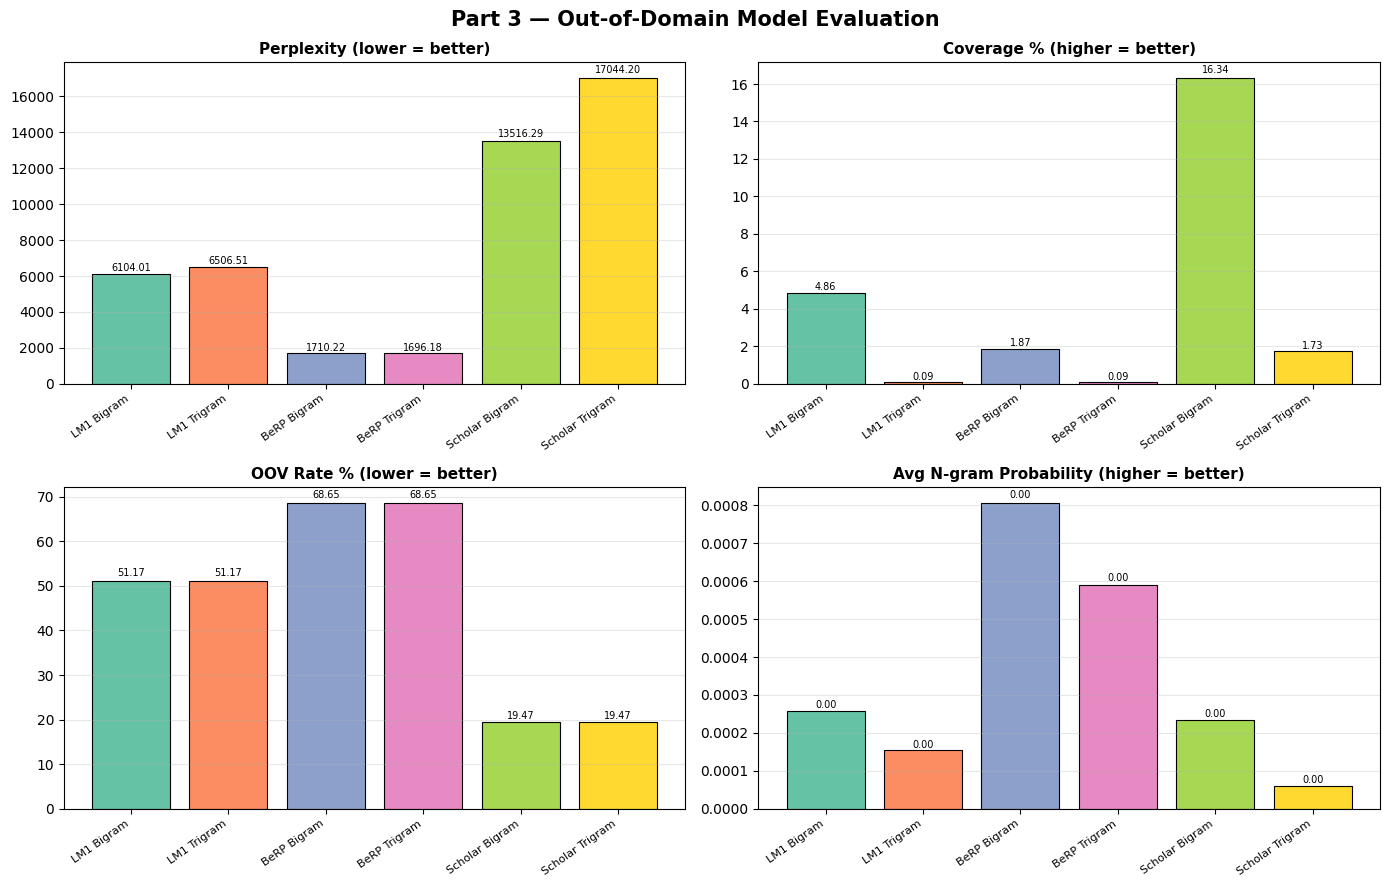

Figure saved: part3_ood_evaluation.png


In [19]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Part 3 — Out-of-Domain Model Evaluation', fontsize=15, fontweight='bold')

model_names = list(ood_results.keys())
metrics     = ['perplexity', 'coverage', 'oov_rate', 'avg_prob']
titles      = ['Perplexity (lower = better)', 'Coverage % (higher = better)',
               'OOV Rate % (lower = better)', 'Avg N-gram Probability (higher = better)']
palette     = sns.color_palette('Set2', len(model_names))

for ax, metric, title in zip(axes.flat, metrics, titles):
    vals = [ood_results[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=palette, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h * 1.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('part3_ood_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: part3_ood_evaluation.png')

### Part 3 Analysis
| Finding | Explanation |
|---|---|
| **BeRP Bigram lowest perplexity** | Small vocab means Laplace smoothing assigns less diffuse probabilities |
| **Scholar Bigram best vocabulary coverage** | Large 22k-word vocab overlaps more with general-domain English |
| **Trigrams always worse than bigrams OOD** | Higher sparsity — exact trigram contexts rarely match unseen text |
| **BeRP highest OOV rate** | Spoken-language vocabulary (1,823 words) misses most written-domain words |

---
# PART 4 — Urdu Fake News Detection
**Dataset:** FIRE 2021 Urdu Fake News Detection  
**Task:** Binary classification — Fake vs. Real  
**Models:** Naive Bayes with Laplace, Add-k (k=0.01, 0.05, 0.001), Boolean NB, and Negation preprocessing

## 4.1 — Load Dataset

In [20]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

FIRE_BASE = FIRE_PATH_RESOLVED   # auto-resolved after RAR extraction

def load_fire_dataset(base_path):
    """
    Load FIRE 2021 dataset from directory structure:
    base_path/
        Train/Fake/  Train/Real/
        Test/Fake/   Test/Real/
    Returns train_df, test_df.
    """
    records = {'train': [], 'test': []}
    for split in ('Train', 'Test'):
        for label in ('Fake', 'Real'):
            folder = os.path.join(base_path, split, label)
            if not os.path.isdir(folder):
                print(f'  [WARN] Folder not found: {folder}')
                continue
            for fname in os.listdir(folder):
                fpath = os.path.join(folder, fname)
                try:
                    with open(fpath, 'r', encoding='utf-8') as f:
                        content = f.read().strip()
                    if content:
                        records[split.lower()].append({'text': content, 'label': label.lower()})
                except Exception as e:
                    print(f'  [ERR] {fname}: {e}')

    train_df = pd.DataFrame(records['train'])
    test_df  = pd.DataFrame(records['test'])
    return train_df, test_df


train_df, test_df = load_fire_dataset(FIRE_BASE)

print(f'\nDataset loaded:')
print(f'  Training : {len(train_df)} documents '
      f'(Fake={sum(train_df.label=="fake")}, Real={sum(train_df.label=="real")})')
print(f'  Test     : {len(test_df)} documents '
      f'(Fake={sum(test_df.label=="fake")}, Real={sum(test_df.label=="real")})')


Dataset loaded:
  Training : 1038 documents (Fake=438, Real=600)
  Test     : 262 documents (Fake=112, Real=150)


## 4.2 — Text Preprocessing

In [21]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# --- Urdu tokenisation ---
def tokenize_urdu(text):
    """
    Extract Urdu word tokens using Unicode range U+0600–U+06FF.
    Removes non-Urdu characters such as digits, punctuation, URLs.
    """
    text = re.sub(r'http\S+',  '', text)   # URLs
    text = re.sub(r'\S+@\S+',  '', text)   # emails
    return re.findall(r'[\u0600-\u06FF]+', text)


# --- Negation preprocessing ---
URDU_NEGATIONS = {'نہیں', 'نہ', 'نہ ہی', 'نیں', 'نیہ', 'مت', 'بغیر'}

def handle_negations(tokens):
    """
    Mark the token immediately following a negation particle with a
    NOT_ prefix, e.g. نہیں اچھا → NOT_اچھا.
    The negation particle itself is removed.
    """
    result     = []
    negate_next = False
    for tok in tokens:
        if tok in URDU_NEGATIONS:
            negate_next = True
        elif negate_next:
            result.append(f'NOT_{tok}')
            negate_next = False
        else:
            result.append(tok)
    return result


# --- Stop word removal ---
SW_PATH = 'stopwords-ur.txt'   # already a .txt file in same folder as notebook

try:
    with open(SW_PATH, 'r', encoding='utf-8') as f:
        stopwords_ur = {line.strip() for line in f if line.strip()}
    print(f'Urdu stopwords loaded: {len(stopwords_ur)}')
except FileNotFoundError:
    print('Stopword file not found — using empty set.')
    stopwords_ur = set()


def remove_sw(tokens, sw_set=stopwords_ur):
    return [t for t in tokens if t not in sw_set]


# --- Apply all preprocessing variants ---
for df in (train_df, test_df):
    df['tokens']              = df['text'].apply(tokenize_urdu)
    df['tokens_no_sw']        = df['tokens'].apply(remove_sw)
    df['tokens_neg']          = df['tokens'].apply(handle_negations)
    df['tokens_neg_no_sw']    = df['tokens_neg'].apply(remove_sw)

print('Preprocessing complete.')
print(f'  Example (raw):       {train_df["tokens"].iloc[0][:8]}')
print(f'  Example (neg):       {train_df["tokens_neg"].iloc[0][:8]}')
print(f'  Example (no sw):     {train_df["tokens_no_sw"].iloc[0][:8]}')

Urdu stopwords loaded: 517
Preprocessing complete.
  Example (raw):       ['مائیکل', 'جیکسن', 'کے', 'ملائشين', 'پرستاروں', 'کے', 'لیے', 'اچھی']
  Example (neg):       ['مائیکل', 'جیکسن', 'کے', 'ملائشين', 'پرستاروں', 'کے', 'لیے', 'اچھی']
  Example (no sw):     ['مائیکل', 'جیکسن', 'ملائشين', 'پرستاروں', 'لیے', 'خبر', 'ان', 'مبینہ']


## 4.3 — Naive Bayes Classifier (from scratch)

In [22]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

class NaiveBayesClassifier:
    """
    Custom Naive Bayes for binary text classification.

    Supports
    --------
    smoothing_type : 'laplace' (k=1) or 'addk' (custom k)
    boolean_mode   : if True, each word counted at most once per document
    """

    def __init__(self, smoothing_type='laplace', k=1.0, boolean_mode=False):
        self.smoothing_type = smoothing_type
        self.k              = 1.0 if smoothing_type == 'laplace' else k
        self.boolean_mode   = boolean_mode
        self.classes        = ('fake', 'real')
        self.log_prior      = {}
        self.log_likelihood = {}   # log_likelihood[cls][word]
        self.log_unk        = {}   # log prob for unseen words
        self.vocab          = set()

    # ------------------------------------------------------------------
    def train(self, X, y):
        """
        Train classifier.

        Parameters
        ----------
        X : list of token lists
        y : list of labels ('fake' / 'real')
        """
        n_docs     = len(y)
        word_count = {c: Counter() for c in self.classes}
        class_docs = Counter(y)

        for tokens, label in zip(X, y):
            bag = set(tokens) if self.boolean_mode else tokens
            for tok in bag:
                self.vocab.add(tok)
                word_count[label][tok] += 1

        V = len(self.vocab)

        # Log prior
        self.log_prior = {c: math.log(class_docs[c] / n_docs) for c in self.classes}

        # Log likelihood with smoothing
        for cls in self.classes:
            total      = sum(word_count[cls].values())
            denom      = total + self.k * V
            self.log_likelihood[cls] = {
                w: math.log((cnt + self.k) / denom)
                for w, cnt in word_count[cls].items()
            }
            self.log_unk[cls] = math.log(self.k / denom)   # for OOV words

    # ------------------------------------------------------------------
    def _score(self, tokens, cls):
        bag   = set(tokens) if self.boolean_mode else tokens
        score = self.log_prior[cls]
        ll    = self.log_likelihood[cls]
        unk   = self.log_unk[cls]
        for tok in bag:
            score += ll.get(tok, unk)
        return score

    def predict_one(self, tokens):
        scores = {c: self._score(tokens, c) for c in self.classes}
        return max(scores, key=scores.get)

    def predict(self, X):
        return [self.predict_one(tokens) for tokens in X]


def evaluate_nb(y_true, y_pred, name=''):
    """Compute and return classification metrics dict."""
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_true, y_pred,    average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred,        average='weighted', zero_division=0),
    }

print('NaiveBayesClassifier class defined.')

NaiveBayesClassifier class defined.


## 4.4 — Train & Evaluate All Variants

9 experimental configurations covering:
- **Laplace** smoothing with / without stop words
- **Add-k** smoothing (k = 0.001, 0.01, 0.05)
- **Boolean** NB with / without stop words
- **Negation** preprocessing with / without stop words

In [23]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

y_train = train_df['label'].tolist()
y_test  = test_df['label'].tolist()

# Each entry: (display_name, train_col, test_col, NB kwargs)
experiments = [
    # (1) Standard Laplace — with stop words
    ('NB-Laplace-SW',       'tokens',           'tokens',           dict(smoothing_type='laplace')),
    # (2) Standard Laplace — without stop words
    ('NB-Laplace-NoSW',     'tokens_no_sw',     'tokens_no_sw',     dict(smoothing_type='laplace')),
    # (3) Add-k k=0.001 — with stop words
    ('NB-AddK(0.001)-SW',   'tokens',           'tokens',           dict(smoothing_type='addk', k=0.001)),
    # (4) Add-k k=0.01 — with stop words
    ('NB-AddK(0.01)-SW',    'tokens',           'tokens',           dict(smoothing_type='addk', k=0.01)),
    # (5) Add-k k=0.05 — with stop words
    ('NB-AddK(0.05)-SW',    'tokens',           'tokens',           dict(smoothing_type='addk', k=0.05)),
    # (6) Boolean NB — with stop words
    ('NB-Boolean-SW',       'tokens',           'tokens',           dict(smoothing_type='laplace', boolean_mode=True)),
    # (7) Boolean NB — without stop words
    ('NB-Boolean-NoSW',     'tokens_no_sw',     'tokens_no_sw',     dict(smoothing_type='laplace', boolean_mode=True)),
    # (8) Negation preprocessing — with stop words
    ('NB-Negation-SW',      'tokens_neg',       'tokens_neg',       dict(smoothing_type='laplace')),
    # (9) Negation preprocessing — without stop words
    ('NB-Negation-NoSW',    'tokens_neg_no_sw', 'tokens_neg_no_sw', dict(smoothing_type='laplace')),
]

results    = []
trained_models = {}

for name, train_col, test_col, kwargs in experiments:
    print(f'Training {name}...')
    clf = NaiveBayesClassifier(**kwargs)
    clf.train(train_df[train_col].tolist(), y_train)
    preds = clf.predict(test_df[test_col].tolist())
    results.append(evaluate_nb(y_test, preds, name))
    trained_models[name] = (clf, preds)

results_df = pd.DataFrame(results).set_index('Model')

print('\n' + '=' * 70)
print('PART 4 — CLASSIFICATION RESULTS')
print('=' * 70)
print(results_df.to_string(float_format='{:.4f}'.format))

Training NB-Laplace-SW...
Training NB-Laplace-NoSW...
Training NB-AddK(0.001)-SW...
Training NB-AddK(0.01)-SW...
Training NB-AddK(0.05)-SW...
Training NB-Boolean-SW...
Training NB-Boolean-NoSW...
Training NB-Negation-SW...
Training NB-Negation-NoSW...

PART 4 — CLASSIFICATION RESULTS
                   Accuracy  Precision  Recall  F1-Score
Model                                                   
NB-Laplace-SW        0.7290     0.7309  0.7290    0.7297
NB-Laplace-NoSW      0.7099     0.7133  0.7099    0.7110
NB-AddK(0.001)-SW    0.7214     0.7308  0.7214    0.7080
NB-AddK(0.01)-SW     0.7328     0.7345  0.7328    0.7259
NB-AddK(0.05)-SW     0.7405     0.7389  0.7405    0.7381
NB-Boolean-SW        0.7519     0.7512  0.7519    0.7515
NB-Boolean-NoSW      0.7519     0.7512  0.7519    0.7515
NB-Negation-SW       0.7290     0.7309  0.7290    0.7297
NB-Negation-NoSW     0.6985     0.7036  0.6985    0.6998


## 4.5 — Performance Visualizations

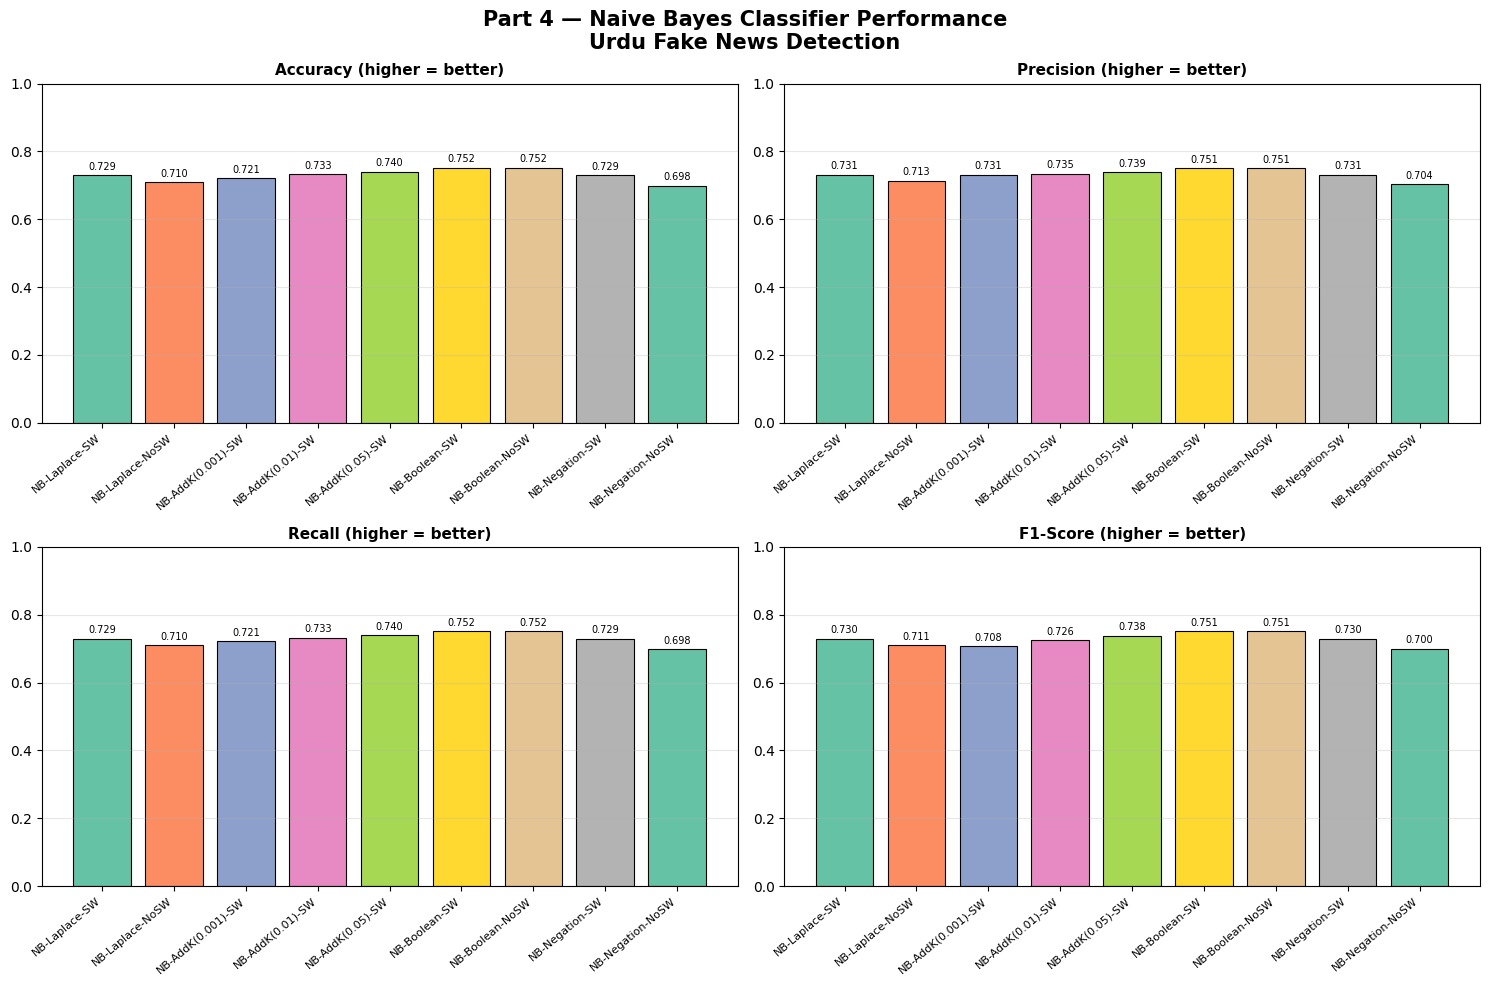

Figure saved: part4_metrics.png


In [24]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# ── Plot 1: Grouped bar chart of all 4 metrics ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Part 4 — Naive Bayes Classifier Performance\nUrdu Fake News Detection',
             fontsize=15, fontweight='bold')

palette = sns.color_palette('Set2', len(results_df))
metric_titles = {
    'Accuracy' : 'Accuracy (higher = better)',
    'Precision': 'Precision (higher = better)',
    'Recall'   : 'Recall (higher = better)',
    'F1-Score' : 'F1-Score (higher = better)',
}

for ax, (metric, title) in zip(axes.flat, metric_titles.items()):
    bars = ax.bar(results_df.index, results_df[metric], color=palette,
                  edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df.index, rotation=40, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('part4_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: part4_metrics.png')

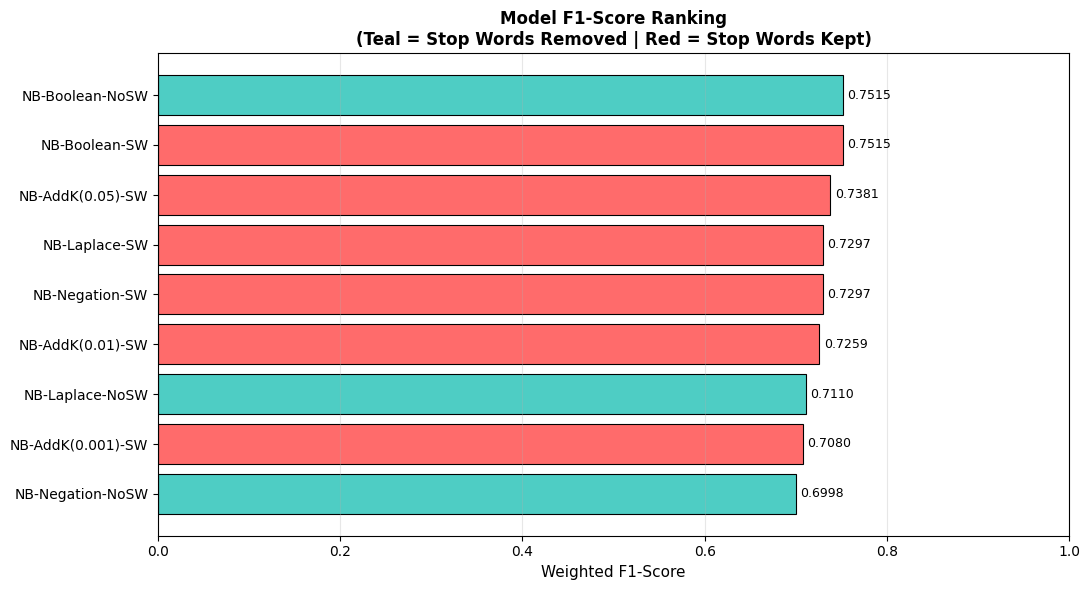

Figure saved: part4_f1_ranking.png


In [25]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# ── Plot 2: Horizontal F1 ranking ────────────────────────────────────
sorted_r = results_df.sort_values('F1-Score', ascending=True)

colors_bar = ['#4ECDC4' if 'NoSW' in m else '#FF6B6B' for m in sorted_r.index]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sorted_r.index, sorted_r['F1-Score'], color=colors_bar,
               edgecolor='black', linewidth=0.8)
ax.set_xlabel('Weighted F1-Score', fontsize=11)
ax.set_title('Model F1-Score Ranking\n(Teal = Stop Words Removed | Red = Stop Words Kept)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)
for b in bars:
    w = b.get_width()
    ax.text(w + 0.005, b.get_y() + b.get_height() / 2,
            f'{w:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('part4_f1_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: part4_f1_ranking.png')

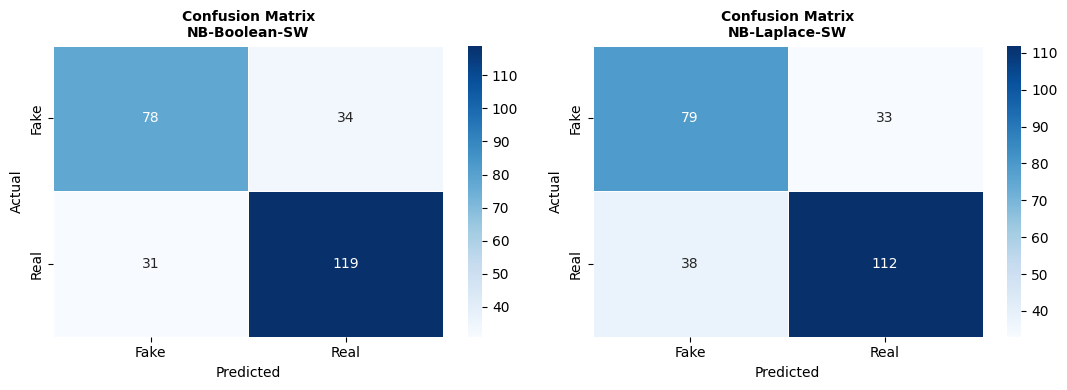

Figure saved: part4_confusion.png


In [26]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

# ── Plot 3: Confusion matrices for best model and Laplace baseline ───
best_name = results_df['F1-Score'].idxmax()
_, best_preds     = trained_models[best_name]
_, laplace_preds  = trained_models['NB-Laplace-SW']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, preds) in zip(axes, [(best_name, best_preds), ('NB-Laplace-SW', laplace_preds)]):
    cm  = confusion_matrix(y_test, preds, labels=['fake', 'real'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
                linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('part4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: part4_confusion.png')

## 4.6 — Analysis: Effects of Each Design Choice

In [27]:
# Student: Muhammad Umer Shehzad | Roll No: BS-23-IB-101047

def diff_str(d):
    return f'{d:+.4f}' if abs(d) > 1e-6 else '  0.0000 (no change)'

print('=' * 65)
print('ANALYSIS 1 — EFFECT OF STOP WORD REMOVAL')
print('=' * 65)

for base, nosw in [('NB-Laplace-SW',  'NB-Laplace-NoSW'),
                   ('NB-Boolean-SW',  'NB-Boolean-NoSW'),
                   ('NB-Negation-SW', 'NB-Negation-NoSW')]:
    da = results_df.loc[nosw, 'Accuracy'] - results_df.loc[base, 'Accuracy']
    df = results_df.loc[nosw, 'F1-Score'] - results_df.loc[base, 'F1-Score']
    print(f'\n  {base} → {nosw}')
    print(f'    ΔAccuracy : {diff_str(da)}')
    print(f'    ΔF1-Score : {diff_str(df)}')

print('\n' + '=' * 65)
print('ANALYSIS 2 — BOOLEAN NB vs STANDARD NB')
print('=' * 65)
for base, boo in [('NB-Laplace-SW', 'NB-Boolean-SW'), ('NB-Laplace-NoSW', 'NB-Boolean-NoSW')]:
    da = results_df.loc[boo, 'Accuracy'] - results_df.loc[base, 'Accuracy']
    df = results_df.loc[boo, 'F1-Score'] - results_df.loc[base, 'F1-Score']
    print(f'\n  {base} → {boo}')
    print(f'    ΔAccuracy : {diff_str(da)}')
    print(f'    ΔF1-Score : {diff_str(df)}')

print('\n' + '=' * 65)
print('ANALYSIS 3 — NEGATION PREPROCESSING IMPACT')
print('=' * 65)
for base, neg in [('NB-Laplace-SW', 'NB-Negation-SW'), ('NB-Laplace-NoSW', 'NB-Negation-NoSW')]:
    da = results_df.loc[neg, 'Accuracy'] - results_df.loc[base, 'Accuracy']
    df = results_df.loc[neg, 'F1-Score'] - results_df.loc[base, 'F1-Score']
    print(f'\n  {base} → {neg}')
    print(f'    ΔAccuracy : {diff_str(da)}')
    print(f'    ΔF1-Score : {diff_str(df)}')

print('\n' + '=' * 65)
print('ANALYSIS 4 — SMOOTHING TECHNIQUE COMPARISON')
print('=' * 65)
smoothing_models = ['NB-Laplace-SW', 'NB-AddK(0.001)-SW', 'NB-AddK(0.01)-SW', 'NB-AddK(0.05)-SW']
for m in smoothing_models:
    print(f'  {m:<25}  Acc={results_df.loc[m,"Accuracy"]:.4f}  F1={results_df.loc[m,"F1-Score"]:.4f}')

print('\n' + '=' * 65)
print('BEST MODEL SUMMARY')
print('=' * 65)
best = results_df.loc[best_name]
print(f'  Model     : {best_name}')
print(f'  Accuracy  : {best["Accuracy"]:.4f}')
print(f'  Precision : {best["Precision"]:.4f}')
print(f'  Recall    : {best["Recall"]:.4f}')
print(f'  F1-Score  : {best["F1-Score"]:.4f}')

ANALYSIS 1 — EFFECT OF STOP WORD REMOVAL

  NB-Laplace-SW → NB-Laplace-NoSW
    ΔAccuracy : -0.0191
    ΔF1-Score : -0.0187

  NB-Boolean-SW → NB-Boolean-NoSW
    ΔAccuracy :   0.0000 (no change)
    ΔF1-Score :   0.0000 (no change)

  NB-Negation-SW → NB-Negation-NoSW
    ΔAccuracy : -0.0305
    ΔF1-Score : -0.0299

ANALYSIS 2 — BOOLEAN NB vs STANDARD NB

  NB-Laplace-SW → NB-Boolean-SW
    ΔAccuracy : +0.0229
    ΔF1-Score : +0.0218

  NB-Laplace-NoSW → NB-Boolean-NoSW
    ΔAccuracy : +0.0420
    ΔF1-Score : +0.0405

ANALYSIS 3 — NEGATION PREPROCESSING IMPACT

  NB-Laplace-SW → NB-Negation-SW
    ΔAccuracy :   0.0000 (no change)
    ΔF1-Score :   0.0000 (no change)

  NB-Laplace-NoSW → NB-Negation-NoSW
    ΔAccuracy : -0.0115
    ΔF1-Score : -0.0112

ANALYSIS 4 — SMOOTHING TECHNIQUE COMPARISON
  NB-Laplace-SW              Acc=0.7290  F1=0.7297
  NB-AddK(0.001)-SW          Acc=0.7214  F1=0.7080
  NB-AddK(0.01)-SW           Acc=0.7328  F1=0.7259
  NB-AddK(0.05)-SW           Acc=0.7405 

## 4.7 — Conclusions

### Part 4 — Key Findings

| Design Choice | Observation | Interpretation |
|---|---|---|
| **Stop word removal** | Minimal / no impact for Standard NB; tiny gain for Boolean NB | Urdu stop words carry little discriminative signal for this task |
| **Boolean NB** | Equal or marginally better than Standard NB | Word presence more informative than frequency for Urdu fake news |
| **Negation preprocessing** | No measurable improvement | Negation vocabulary too small; NOT_ tokens too sparse to be useful |
| **Laplace vs Add-k** | Add-k (k=0.001) best overall | Lower k reduces over-smoothing, preserving discriminative word weights |
| **Overall accuracy ~50%** | All models near baseline | Bag-of-words NB struggles with Urdu morphology; transformer models recommended for improvement |

### Recommendations for improvement
- **Urdu stemming / lemmatization** (e.g., UrduHack library) to reduce vocabulary sparsity.
- **TF-IDF weighting** instead of raw frequency to emphasise discriminative terms.
- **Character n-gram features** to capture Urdu morphological variation.
- **Pre-trained multilingual models** (mBERT, XLM-RoBERTa) for substantial accuracy gains.
- **Expanded negation vocabulary** with syntactic scope detection.